In [ ]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
sys.path.append('../../../')
from mount_drive import mount_s_drive

In [4]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
sys.path.insert(0, dir1)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.impute import KNNImputer
from eICUUtil import *

Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.


In [5]:
# myPredictorsDf.treatment_hypothermia.sum()

In [6]:
from econml.dml import CausalForestDML, SparseLinearDML, LinearDML, DML
from econml.orf import DMLOrthoForest
from econml.dr import LinearDRLearner
myTreatment = 'both_hypothermia'
myPredicted = 'LastMGCSPositive'
myPredictorsDf, X_train_no_group, X_test_no_group, T_train, T_test, y_train, y_test =  \
                    getTrainTestFunctions(aPredictedColumn = myPredicted, 
                                            aTreatmentColumn = myTreatment, aTreatmentSplit = True, aSkipTemp = True, 
                                            aDropColumns = 
                                            ['Hypothermia', 'treatment_therapy for controlling cerebral perfusion pressure', 
                                                 'treatment_neurologic', 'treatment_neuromuscular blocking agent', 'treatment_subcutaneous'], 
                                            aTestSize=.3) 
causal_forest = CausalForestDML(
    model_y= XGBClassifier(max_depth=25, n_estimators=100),  
    model_t= XGBClassifier(max_depth=10, n_estimators=20),    
    discrete_treatment=True,           
    discrete_outcome=True,
    verbose=2,
    n_jobs=-1
)

Columns (2059,2070,2081,2083,2084,2089,2095,2099,2108,2119,2130,2132,2133,2138,2144,2148,2305,2307) have mixed types. Specify dtype option on import or set low_memory=False.


In [7]:
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    return [('preprocessor', myPreprocessor), ('imputer', KNNImputer(n_neighbors=10)), ('pca', PCA(0.99))]

In [8]:
myPipeline = Pipeline(getDefaultPipelineSteps(X_train_no_group))

In [9]:
myNewXTrain = pd.DataFrame(myPipeline.fit_transform(X_train_no_group), columns = myPipeline.get_feature_names_out())
myNewXTest = pd.DataFrame(myPipeline.transform(X_test_no_group), columns = myPipeline.get_feature_names_out())


In [10]:
causal_forest.fit(y_train, T_train, X=myNewXTrain, cache_values=True)
print(causal_forest.score(y_train, T_train, X=myNewXTrain))

CATE_pred = causal_forest.effect(myNewXTrain)

print(f'Feature importances {causal_forest.feature_importances_}')

print("Predicted CATE for test data:", CATE_pred[:10])

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    1.7s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.1s finished


0.05545660863147842
Feature importances [6.58076942e-04 6.98435133e-03 5.38078050e-03 7.70383321e-03
 1.26571570e-02 5.73218824e-03 5.36484236e-03 6.60139868e-03
 1.09073636e-03 2.33338403e-04 1.09365021e-02 1.05219367e-02
 6.64277882e-04 4.54986977e-03 1.23979858e-03 6.44909633e-03
 5.85985957e-03 4.24323551e-03 1.92856501e-03 1.54519849e-03
 2.80660119e-04 4.36146844e-05 1.16712183e-02 3.46019151e-04
 3.50190192e-03 1.38456289e-03 2.11021678e-03 7.44479559e-03
 6.03116639e-03 1.18947332e-03 4.01502918e-03 6.20678276e-03
 3.59436461e-03 1.91179002e-03 1.00647952e-02 4.01766916e-03
 3.75647075e-03 4.89699448e-03 1.56831630e-03 3.85582212e-04
 1.90811010e-03 3.03327326e-03 4.90210332e-03 1.58929799e-04
 8.15371955e-04 5.48484175e-03 1.85995534e-03 7.08619074e-04
 2.28487098e-03 8.61687165e-04 8.82899745e-04 2.55955270e-03
 6.26515869e-03 2.88032623e-03 1.56667413e-03 1.37316710e-03
 8.57909226e-04 8.13989335e-04 2.54257985e-03 2.83127683e-03
 3.51523295e-03 1.51948295e-03 3.20598779e-03

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.0s finished


In [16]:
causal_forest.summary()

Population summary of CATE predictions on Training Data


[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.2s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.2s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  12 out of  25 | elapsed:    0.2s remaining:    0.2s
[Parallel(n_jobs=20)]: Done  25 out of  25 | elapsed:    0.2s remaining:    0.0s
[Parallel(n_jobs=20)]: Done  25 out of  25 | elapsed:    0.2s finished


<class 'econml.utilities.Summary'>
"""
               Uncertainty of Mean Point Estimate               
================================================================
mean_point stderr_mean zstat  pvalue ci_mean_lower ci_mean_upper
----------------------------------------------------------------
    -0.034       0.096 -0.353  0.724        -0.222         0.154
      Distribution of Point Estimate     
=========================================
std_point pct_point_lower pct_point_upper
-----------------------------------------
    0.047          -0.128           0.063
     Total Variance of Point Estimate     
==========================================
stderr_point ci_point_lower ci_point_upper
------------------------------------------
       0.107         -0.246          0.178
       Doubly Robust ATE on Training Data Results       
========================================================
    point_estimate stderr zstat pvalue ci_lower ci_upper
--------------------------------------------------------
ATE          0.024  0.063 0.378  0.706     -0.1    0.148
     Doubly Robust ATT(T=0) on Training Data Results     
=========================================================
    point_estimate stderr zstat  pvalue ci_lower ci_upper
---------------------------------------------------------
ATT         -0.149  0.025 -5.946    0.0   -0.198     -0.1
    Doubly Robust ATT(T=1) on Training Data Results     
========================================================
    point_estimate stderr zstat pvalue ci_lower ci_upper
--------------------------------------------------------
ATT          0.332  0.169 1.965  0.049    0.001    0.663
--------------------------------------------------------

Note: The stderr_mean is a conservative upper bound.
"""

In [31]:
myNewFeaturesDf = pd.DataFrame(np.array([causal_forest.feature_importances_]), columns = myPipeline.get_feature_names_out())

In [32]:
myColumns = myNewFeaturesDf.loc[:, myNewFeaturesDf.sum().nlargest(15).index].columns
myColumns

Index(['num__lab_mean_troponin - T', 'num__lab_min_ALT (SGPT)',
       'num__nurse_max_Respiratory Rate', 'num__lab_min_Total CO2',
       'num__lab_max_free T4', 'num__nurse_last_Non-Invasive BP Systolic',
       'num__nurse_mean_CI', 'num__nurse_max_PA Systolic',
       'num__lab_max_-monos', 'num__FirstGCS', 'num__lab_last_paCO2',
       'num__lab_mean_Ferritin', 'num__lab_max_Methemoglobin',
       'num__nurse_min_Invasive BP Diastolic', 'num__lab_max_ionized calcium'],
      dtype='object')

In [33]:
myMainColumns = myColumns.str.split('__').str[-1]

In [41]:
myMainColumns

Index(['lab_mean_troponin - T', 'lab_min_ALT (SGPT)',
       'nurse_max_Respiratory Rate', 'lab_min_Total CO2', 'lab_max_free T4',
       'nurse_last_Non-Invasive BP Systolic', 'nurse_mean_CI',
       'nurse_max_PA Systolic', 'lab_max_-monos', 'FirstGCS', 'lab_last_paCO2',
       'lab_mean_Ferritin', 'lab_max_Methemoglobin',
       'nurse_min_Invasive BP Diastolic', 'lab_max_ionized calcium'],
      dtype='object')

In [34]:
# myNewXTest = myPipeline.transform(X_test_no_group)
causal_forest.score(y_test, T_test, myNewXTest)

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.0s finished


0.1972503817988958

In [39]:
myNewXTest = pd.DataFrame(myPipeline.transform(X_test_no_group), columns = myPipeline.get_feature_names_out())


In [43]:
myData = pd.concat([myNewXTrain.reset_index(), myNewDf.reset_index(), T_train.reset_index(), y_train_df.reset_index()], axis=1)
myData['TreatmentColumn'] = myData[myTreatment]
myData.columns = myData.columns.str.replace(' ', '_')
myData.columns = myData.columns.str.replace('-', '_')
myData.columns = myData.columns.str.replace('(', '_')
myData.columns = myData.columns.str.replace(')', '_')
myColumns2 = myColumns.str.replace(' ', '_')
myColumns2 = myColumns2.str.replace('-', '_')
myColumns2 = myColumns2.str.replace('(', '_')
myColumns2 = myColumns2.str.replace(')', '_')
string = ''
for column in myColumns2:
    string += f'{column}* TreatmentColumn + '
myInteractionModel = smf.logit(
    f'{myPredicted} ~ ' + string + 'TreatmentColumn' ,
    data=myData
).fit()
myInteractionModel.summary()

Optimization terminated successfully.
         Current function value: 0.614508
         Iterations 6


The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:       DeathAtDischarge   No. Observations:                 1726
Model:                          Logit   Df Residuals:                     1694
Method:                           MLE   Df Model:                           31
Date:                Sun, 02 Mar 2025   Pseudo R-squ.:                 0.09467
Time:                        15:21:55   Log-Likelihood:                -1060.6
converged:                       True   LL-Null:                       -1171.6
Covariance Type:            nonrobust   LLR p-value:                 1.045e-30
============================================================================================================================
                                                               coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------
Intercept                                                    0.4647      0.116      4.010      0.000       0.238       0.692
num__lab_mean_troponin___T                                  -0.2460      0.195     -1.263      0.207      -0.628       0.136
TreatmentColumn                                              0.2248      0.260      0.866      0.387      -0.284       0.734
num__lab_mean_troponin___T:TreatmentColumn                   0.2423      0.250      0.969      0.333      -0.248       0.733
num__lab_min_ALT__SGPT_                                      0.1835      0.088      2.090      0.037       0.011       0.356
num__lab_min_ALT__SGPT_:TreatmentColumn                      0.1975      0.235      0.840      0.401      -0.263       0.658
num__nurse_max_Respiratory_Rate                              0.1729      0.086      2.017      0.044       0.005       0.341
num__nurse_max_Respiratory_Rate:TreatmentColumn             -0.2338      0.139     -1.681      0.093      -0.506       0.039
num__lab_min_Total_CO2                                      -0.0660      0.111     -0.596      0.551      -0.283       0.151
num__lab_min_Total_CO2:TreatmentColumn                      -0.0780      0.210     -0.371      0.711      -0.490       0.334
num__lab_max_free_T4                                        -0.1516      0.213     -0.711      0.477      -0.570       0.266
num__lab_max_free_T4:TreatmentColumn                         0.0802      0.572      0.140      0.888      -1.040       1.201
num__nurse_last_Non_Invasive_BP_Systolic                    -0.1220      0.064     -1.913      0.056      -0.247       0.003
num__nurse_last_Non_Invasive_BP_Systolic:TreatmentColumn     0.2356      0.142      1.660      0.097      -0.043       0.514
num__nurse_mean_CI                                           0.4910      0.224      2.197      0.028       0.053       0.929
num__nurse_mean_CI:TreatmentColumn                          -0.1960      0.475     -0.413      0.680      -1.127       0.735
num__nurse_max_PA_Systolic                                   0.5500      0.350      1.570      0.116      -0.136       1.236
num__nurse_max_PA_Systolic:TreatmentColumn                   0.7307      0.823      0.887      0.375      -0.883       2.344
num__lab_max__monos                                         -0.1819      0.073     -2.484      0.013      -0.325      -0.038
num__lab_max__monos:TreatmentColumn                         -0.0089      0.162     -0.055      0.956      -0.326       0.309
num__FirstGCS                                               -0.5423      0.066     -8.273      0.000      -0.671      -0.414
num__FirstGCS:TreatmentColumn                               -0.0428      0.166     -0.258      0.797      -0.368       0.283
num__lab_last_paCO2                                          0.1708      0.072      2.381      0.017       0.030    

In [44]:
myData = pd.concat([myNewXTrain.reset_index(), myNewDf.reset_index(), T_train.reset_index(), y_train_df.reset_index()], axis=1)
myData['TreatmentColumn'] = myData[myTreatment]
myData.columns = myData.columns.str.replace(' ', '_')
myData.columns = myData.columns.str.replace('-', '_')
myData.columns = myData.columns.str.replace('(', '_')
myData.columns = myData.columns.str.replace(')', '_')
myColumns2 = myColumns.str.replace(' ', '_')
myColumns2 = myColumns2.str.replace('-', '_')
myColumns2 = myColumns2.str.replace('(', '_')
myColumns2 = myColumns2.str.replace(')', '_')
string = ''
for column in myColumns2:
    string += f'{column} + '
myNoInteractionModel = smf.logit(
    f'{myPredicted} ~ ' + string + 'TreatmentColumn' ,
    data=myData
).fit()
myNoInteractionModel.summary()

Optimization terminated successfully.
         Current function value: 0.617501
         Iterations 6


The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:       DeathAtDischarge   No. Observations:                 1726
Model:                          Logit   Df Residuals:                     1709
Method:                           MLE   Df Model:                           16
Date:                Sun, 02 Mar 2025   Pseudo R-squ.:                 0.09026
Time:                        15:22:25   Log-Likelihood:                -1065.8
converged:                       True   LL-Null:                       -1171.6
Covariance Type:            nonrobust   LLR p-value:                 3.729e-36
============================================================================================================
                                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
Intercept                                    0.5054      0.105      4.813      0.000       0.300       0.711
num__lab_mean_troponin___T                  -0.1030      0.116     -0.890      0.373      -0.330       0.124
num__lab_min_ALT__SGPT_                      0.2161      0.083      2.613      0.009       0.054       0.378
num__nurse_max_Respiratory_Rate              0.1013      0.065      1.554      0.120      -0.026       0.229
num__lab_min_Total_CO2                      -0.0962      0.095     -1.013      0.311      -0.282       0.090
num__lab_max_free_T4                        -0.1371      0.195     -0.704      0.481      -0.519       0.244
num__nurse_last_Non_Invasive_BP_Systolic    -0.0748      0.056     -1.328      0.184      -0.185       0.036
num__nurse_mean_CI                           0.4398      0.196      2.247      0.025       0.056       0.823
num__nurse_max_PA_Systolic                   0.6403      0.313      2.048      0.041       0.027       1.253
num__lab_max__monos                         -0.1807      0.065     -2.783      0.005      -0.308      -0.053
num__FirstGCS                               -0.5455      0.060     -9.156      0.000      -0.662      -0.429
num__lab_last_paCO2                          0.1662      0.062      2.681      0.007       0.045       0.288
num__lab_mean_Ferritin                       0.3139      0.219      1.433      0.152      -0.115       0.743
num__lab_max_Methemoglobin                  -0.2188      0.104     -2.108      0.035      -0.422      -0.015
num__nurse_min_Invasive_BP_Diastolic        -0.2338      0.082     -2.862      0.004      -0.394      -0.074
num__lab_max_ionized_calcium                -0.0278      0.087     -0.322      0.748      -0.197       0.142
TreatmentColumn                              0.0308      0.126      0.244      0.807      -0.217       0.279
============================================================================================================
"""

In [45]:
myInteractionModel.pvalues[myInteractionModel.pvalues < 0.05].index

Index(['Intercept', 'num__lab_min_ALT__SGPT_',
       'num__nurse_max_Respiratory_Rate', 'num__nurse_mean_CI',
       'num__lab_max__monos', 'num__FirstGCS', 'num__lab_last_paCO2',
       'num__nurse_min_Invasive_BP_Diastolic'],
      dtype='object')

In [47]:
myColumns3 = list(myInteractionModel.pvalues[myInteractionModel.pvalues < 0.05].index)

In [48]:
string = ''
for column in myColumns3:
    if ':' in column:
        column = column.split(':')[0]
    if column != 'Intercept':
        string += f'{column}* TreatmentColumn + '
myInteractionModel = smf.logit(
    f'{myPredicted} ~ ' + string + 'TreatmentColumn',
    data=myData
).fit()
myInteractionModel.summary()

Optimization terminated successfully.
         Current function value: 0.620649
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:       DeathAtDischarge   No. Observations:                 1726
Model:                          Logit   Df Residuals:                     1710
Method:                           MLE   Df Model:                           15
Date:                Sun, 02 Mar 2025   Pseudo R-squ.:                 0.08562
Time:                        15:23:06   Log-Likelihood:                -1071.2
converged:                       True   LL-Null:                       -1171.6
Covariance Type:            nonrobust   LLR p-value:                 1.586e-34
========================================================================================================================
                                                           coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------
Intercept                                                0.4677      0.065      7.175      0.000       0.340       0.595
num__lab_min_ALT__SGPT_                                  0.1758      0.083      2.112      0.035       0.013       0.339
TreatmentColumn                                         -0.0477      0.145     -0.328      0.743      -0.333       0.237
num__lab_min_ALT__SGPT_:TreatmentColumn                  0.1954      0.227      0.860      0.390      -0.250       0.641
num__nurse_max_Respiratory_Rate                          0.2082      0.082      2.543      0.011       0.048       0.369
num__nurse_max_Respiratory_Rate:TreatmentColumn         -0.2103      0.131     -1.601      0.109      -0.468       0.047
num__nurse_mean_CI                                       0.4711      0.219      2.150      0.032       0.042       0.901
num__nurse_mean_CI:TreatmentColumn                      -0.1959      0.465     -0.421      0.674      -1.107       0.715
num__lab_max__monos                                     -0.1858      0.072     -2.581      0.010      -0.327      -0.045
num__lab_max__monos:TreatmentColumn                      0.0221      0.158      0.140      0.889      -0.288       0.332
num__FirstGCS                                           -0.5350      0.061     -8.757      0.000      -0.655      -0.415
num__FirstGCS:TreatmentColumn                           -0.0041      0.159     -0.026      0.979      -0.317       0.308
num__lab_last_paCO2                                      0.1642      0.068      2.432      0.015       0.032       0.297
num__lab_last_paCO2:TreatmentColumn                     -0.0263      0.140     -0.188      0.851      -0.300       0.248
num__nurse_min_Invasive_BP_Diastolic                    -0.3285      0.098     -3.361      0.001      -0.520      -0.137
num__nurse_min_Invasive_BP_Diastolic:TreatmentColumn     0.2174      0.178      1.222      0.222      -0.131       0.566
========================================================================================================================
"""

In [49]:
string = ''
for column in myColumns3:
    if ':' in column:
        column = column.split(':')[0]
    if column != 'Intercept':
        string += f'{column} + '
myNoInteractionModel = smf.logit(
    f'{myPredicted} ~ ' + string + 'TreatmentColumn',
    data=myData
).fit()
myNoInteractionModel.summary()

Optimization terminated successfully.
         Current function value: 0.622210
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:       DeathAtDischarge   No. Observations:                 1726
Model:                          Logit   Df Residuals:                     1717
Method:                           MLE   Df Model:                            8
Date:                Sun, 02 Mar 2025   Pseudo R-squ.:                 0.08332
Time:                        15:23:12   Log-Likelihood:                -1073.9
converged:                       True   LL-Null:                       -1171.6
Covariance Type:            nonrobust   LLR p-value:                 6.434e-38
========================================================================================================
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
Intercept                                0.4478      0.063      7.078      0.000       0.324       0.572
num__lab_min_ALT__SGPT_                  0.2086      0.079      2.634      0.008       0.053       0.364
num__nurse_max_Respiratory_Rate          0.1396      0.062      2.236      0.025       0.017       0.262
num__nurse_mean_CI                       0.4164      0.192      2.167      0.030       0.040       0.793
num__lab_max__monos                     -0.1830      0.064     -2.860      0.004      -0.308      -0.058
num__FirstGCS                           -0.5381      0.056     -9.570      0.000      -0.648      -0.428
num__lab_last_paCO2                      0.1572      0.059      2.678      0.007       0.042       0.272
num__nurse_min_Invasive_BP_Diastolic    -0.2693      0.081     -3.343      0.001      -0.427      -0.111
TreatmentColumn                          0.0083      0.125      0.066      0.947      -0.237       0.253
========================================================================================================
"""

In [50]:
llr = -2*(myNoInteractionModel.llf - myInteractionModel.llf)
df_diff = myInteractionModel.df_model - myNoInteractionModel.df_model
p_value = chi2.sf(llr, df_diff)

print(f'Likelihood ratio of test results:')
print(f'Chi square statistic: {llr}')
print(f'p-value: {p_value}')
print(f'Degress of freedom: {df_diff}')

Likelihood ratio of test results:
Chi square statistic: 5.3870208569242095
p-value: 0.6128439227802598
Degress of freedom: 7.0


In [60]:
causal_forest.get_model_t().predict(myNewXTrain)

AttributeError: 'CausalForestDML' object has no attribute 'get_model_t'

Optimization terminated successfully.
         Current function value: 0.629859
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.629201
         Iterations 5
Likelihood ratio of test results:
Chi square statistic: 1.994581956384991
p-value: 0.15786261897256695
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:       LastMGCSPositive   No. Observations:                 1517
Model:                          Logit   Df Residuals:                     1514
Method:                           MLE   Df Model:                            2
Date:                Mon, 10 Mar 2025   Pseudo R-squ.:                 0.01210
Time:                        09:12:38   Log-Likelihood:                -955.50
converged:                       True   LL-Null:                       -967.20
Covariance Type:            nonrobust   LLR p-value:                 8.249e-06
                      

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.0s finished


0.15786261897256695

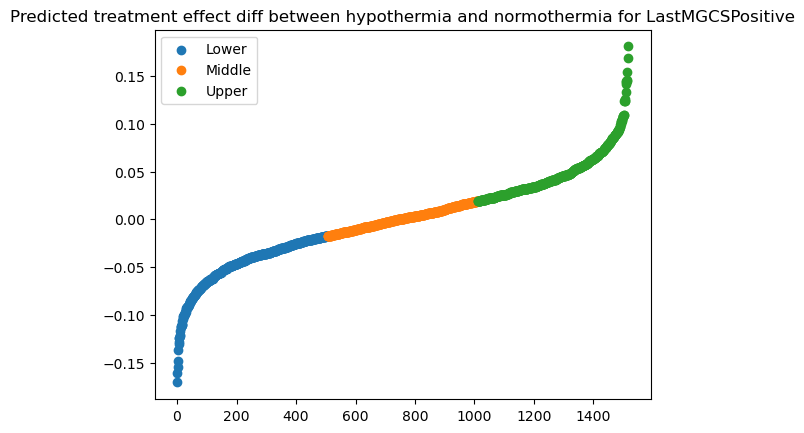

In [54]:
# myNewXTrain = pd.DataFrame(myPipeline.transform(X_train_no_group), columns = myPipeline.get_feature_names_out())
CATE_pred = causal_forest.effect(myNewXTrain)

myNewDf = pd.DataFrame()
myNewDf['predicted_effect'] = CATE_pred[:, 0]
lower_third, upper_third, _ = getPredictedThirds(myNewDf)
plotPredictedTreatmentEffect(myNewDf, myPredicted)
# myNewDf['predicted_effect_group'] = (myNewDf['predicted_effect'] > 0).astype(str)

X_train_new = X_train_no_group.copy().reset_index()
X_train_new[myTreatment] = T_train.reset_index()[myTreatment]
y_train_df = pd.DataFrame()
y_train_df[myPredicted] = y_train.reset_index()[myPredicted]
getTreatmentEffectDiffDataFrame(X_train_new, y_train_df, myNewDf, myPredicted, myTreatment, False)

In [99]:
pd.DataFrame((cate_upper < 0) & (cate_lower < 0)).sum()

0    1
dtype: int64

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  12 out of  25 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=20)]: Done  25 out of  25 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=20)]: Done  25 out of  25 | elapsed:    0.1s finished


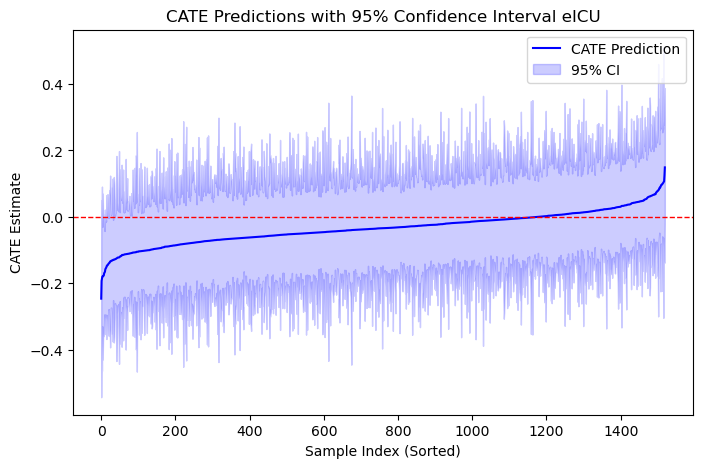

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Compute CATE prediction intervals
CATE_pred = causal_forest.effect(myNewXTrain)

cate_lower, cate_upper = causal_forest.effect_interval(myNewXTrain, alpha=0.05)

# Ensure arrays are 1D NumPy arrays
CATE_pred = np.array(CATE_pred).flatten()
cate_lower = np.array(cate_lower).flatten()
cate_upper = np.array(cate_upper).flatten()

# Sort values for a cleaner plot
sorted_idx = np.argsort(CATE_pred)
cate_pred_sorted = CATE_pred[sorted_idx]
cate_lower_sorted = cate_lower[sorted_idx]
cate_upper_sorted = cate_upper[sorted_idx]

# Create x-axis index
x = np.arange(len(cate_pred_sorted))

# Plot CATE predictions
plt.figure(figsize=(8, 5))
plt.plot(x, cate_pred_sorted, label='CATE Prediction', color='blue')

# Fill confidence interval
plt.fill_between(x, cate_lower_sorted, cate_upper_sorted, 
                 color='blue', alpha=0.2, label='95% CI')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
# Labels and title
plt.xlabel("Sample Index (Sorted)")
plt.ylabel("CATE Estimate")
plt.title("CATE Predictions with 95% Confidence Interval eICU")
plt.legend()
plt.show()


Optimization terminated successfully.
         Current function value: 0.628600
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.626609
         Iterations 5
Likelihood ratio of test results:
Chi square statistic: 2.591698864557088
p-value: 0.10742505625339853
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:       LastMGCSPositive   No. Observations:                  651
Model:                          Logit   Df Residuals:                      648
Method:                           MLE   Df Model:                            2
Date:                Mon, 10 Mar 2025   Pseudo R-squ.:                 0.01243
Time:                        09:12:54   Log-Likelihood:                -409.22
converged:                       True   LL-Null:                       -414.37
Covariance Type:            nonrobust   LLR p-value:                  0.005786
                      

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.0s finished


0.10742505625339853

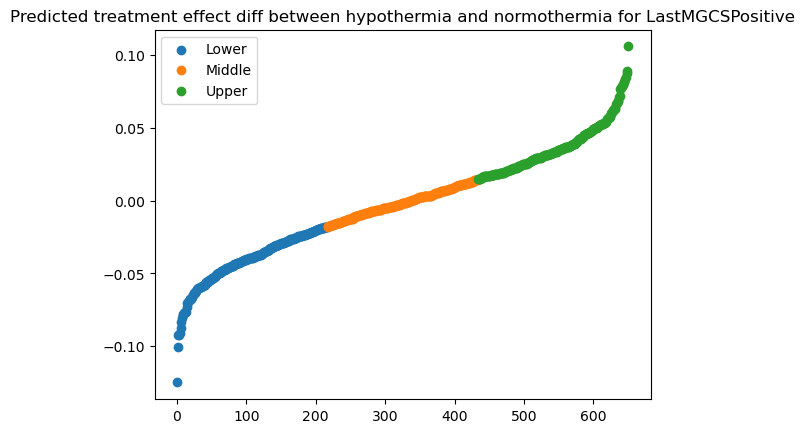

In [56]:
# myNewXTest = myPipeline.transform(X_test_no_group)
CATE_pred = causal_forest.effect(myNewXTest)

myNewDf = pd.DataFrame()
myNewDf['predicted_effect'] = CATE_pred[:, 0]
lower_third, upper_third, _ = getPredictedThirds(myNewDf)
plotPredictedTreatmentEffect(myNewDf, myPredicted)
myNewDf['predicted_effect_group'] = (myNewDf['predicted_effect'] > 0).astype(str)


X_test_new = X_test_no_group.copy().reset_index()
X_test_new[myTreatment] = T_test.reset_index()[myTreatment]
y_test_df = pd.DataFrame()
y_test_df[myPredicted] = y_test.reset_index()[myPredicted]
getTreatmentEffectDiffDataFrame(X_test_new, y_test_df, myNewDf, myPredicted, myTreatment, False)

In [100]:
myNewDf[myPredicted]= y_train.reset_index()[myPredicted]
myNewDf[myTreatment]= T_train.reset_index()[myTreatment]

In [101]:
myGroup = myNewDf.groupby(['predicted_effect_group', myTreatment]).agg({myPredicted:'sum', 'index':'count'})
myGroup = myGroup.reset_index()
myGroup['percent'] = myGroup[myPredicted] / myGroup['index']
myGroup
# does not mean anything because you don't know the baseline effect

,predicted_effect_group,both_hypothermia,LastMGCSPositive,index,percent
0,False,0,120,289,0.415225
1,False,1,26,107,0.242991
2,True,0,123,257,0.478599
3,True,1,27,125,0.216000


In [102]:
# test_stat = causal_forest.test_stat(X_test)

In [236]:
myNewXTest = pd.DataFrame(myPipeline.transform(X_test_no_group), columns = myPipeline.get_feature_names_out())
CATE_pred = causal_forest.effect(myNewXTest)

from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=1e-3)  # Adjust threshold as needed
myNewXTest = selector.fit_transform(myNewXTest)

X_test_const = sm.add_constant(myNewXTest)

# Fit logistic regression (binary effect variable)
logit_model = sm.OLS(CATE_pred, X_test_const).fit()
logit_model.summary()

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.0s finished


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.598
Model:                            OLS   Adj. R-squared:                  0.588
Method:                 Least Squares   F-statistic:                     56.40
Date:                Tue, 25 Feb 2025   Prob (F-statistic):          5.42e-135
Time:                        08:52:50   Log-Likelihood:                 1062.3
No. Observations:                 778   AIC:                            -2083.
Df Residuals:                     757   BIC:                            -1985.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0639      0.004    -16.589      0.000      -0.071      -0.056
x1            -0.0699      0.006    -11.883      0.000      -0.081      -0.058
x2             0.0481      0.010      4.635      0.000       0.028       0.068
x3            -0.0478      0.006     -7.363      0.000      -0.061      -0.035
x4             0.0123      0.008      1.556      0.120      -0.003       0.028
x5            -0.0054      0.006     -0.872      0.383      -0.017       0.007
x6             0.0143      0.007      1.973      0.049    7.33e-05       0.028
x7            -0.0150      0.010     -1.439      0.151      -0.036       0.005
x8            -0.0041      0.003     -1.240      0.216      -0.011       0.002
x9            -0.0143      0.013     -1.128      0.260      -0.039       0.011
x10            0.0067      0.003      2.605      0.009       0.002       0.012
x11           -0.0019      0.003     -0.741      0.459      -0.007       0.003
x12           -0.0037      0.008     -0.462      0.644      -0.019       0.012
x13            0.0002      0.004      0.037      0.970      -0.009       0.009
x14           -0.0301      0.011     -2.798      0.005      -0.051      -0.009
x15            0.0326      0.005      6.887      0.000       0.023       0.042
x16            0.0052      0.003      2.005      0.045       0.000       0.010
x17           -0.0502      0.013     -3.885      0.000      -0.076      -0.025
x18           -0.0099      0.003     -3.117      0.002      -0.016      -0.004
x19            0.0035      0.004      0.913      0.362      -0.004       0.011
x20           -0.0147      0.006     -2.627      0.009      -0.026      -0.004
==============================================================================
Omnibus:                        5.221   Durbin-Watson:                   2.109
Prob(Omnibus):                  0.074   Jarque-Bera (JB):                5.968
Skew:                          -0.096   Prob(JB):                       0.0506
Kurtosis:                       3.384   Cond. No.                         10.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [89]:
myNewXTest.shape

(778, 1942)

In [82]:
CATE_pred.

(778, 1)